# TF-IDF + Logistic Regression

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("bethesda-classification")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

## Служебная информация об эксперименте

Фиксируем имя участника, название задачи, дату и текущий Git commit.

Git commit используется как идентификатор версии кода. Перед запуском модели
необходимо убедиться, что код эксперимента закоммичен. Если в рабочей директории
есть незакоммиченные изменения, текущий commit не полностью описывает состояние
кода, на котором выполняется эксперимент.

In [37]:
import subprocess
from datetime import datetime


participant = "Savely"
task_name = "bethesda-classification"

# Получаем SHA текущего Git-коммита
git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True,
).strip()

# Проверяем наличие незакоммиченных изменений
git_status = subprocess.check_output(
    ["git", "status", "--porcelain"],
    text=True,
).strip()

run_date = datetime.now().strftime("%d-%m-%Y")

print("Participant:", participant)
print("Task:", task_name)
print("Date:", run_date)
print("Git commit:", git_commit)

if git_status:
    print("\nWARNING: в репозитории есть незакоммиченные изменения.")
    print("Перед первым MLflow run необходимо сделать commit и повторно выполнить эту ячейку.")
else:
    print("\nGit working tree clean.")

Participant: Savely
Task: bethesda-classification
Date: 11-10-2026
Git commit: 710bcc7da47d34a67df079aa4de12cb7a1966713

Git working tree clean.


## Версия датасета

Для экспериментов используется актуальный `prepared_dataset.csv`.

Версия данных определяется полным SHA256-хешем файла. Если содержимое датасета
изменится хотя бы на уровне одного байта, изменится и его SHA256.

Полный SHA256 будет сохраняться в каждом MLflow run как `dataset_version`.
Первые 12 символов используются только для удобного отображения и имени
архивной копии датасета.

In [3]:
from pathlib import Path

from src.common.dataset_versioning import calculate_sha256


# Определяем корень проекта
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(
        path
        for path in PROJECT_ROOT.parents
        if (path / "src").exists()
    )

# Актуальный воспроизводимый датасет
dataset_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "prepared_dataset.csv"
)

if not dataset_path.exists():
    raise FileNotFoundError(
        f"Датасет не найден: {dataset_path}"
    )

# Вычисляем версию данных
dataset_hash = calculate_sha256(dataset_path)
dataset_version_short = dataset_hash[:12]

# Ожидаемая архивная копия этой версии
dataset_version_path = (
    dataset_path.parent
    / "versions"
    / f"{dataset_path.stem}_{dataset_version_short}{dataset_path.suffix}"
)

print("Dataset:", dataset_path.name)
print("Dataset version:", dataset_version_short)
print("Full SHA256:", dataset_hash)
print("Archived version:", dataset_version_path.name)
print("Archive exists:", dataset_version_path.exists())

Dataset: prepared_dataset.csv
Dataset version: e88b34b729ea
Full SHA256: e88b34b729eaf057b6f2a7deeae7fcfce901da710ddce628a329d9d96aaad724
Archived version: prepared_dataset_e88b34b729ea.csv
Archive exists: True


## Загрузка и первичная проверка датасета

Загрузим актуальный `prepared_dataset.csv`, для которого выше был вычислен
SHA256-хеш.

Проверим размер датасета, структуру столбцов и первые строки. На этом этапе
модель ещё не обучается, поэтому отдельный MLflow run не создаётся.

In [8]:
import pandas as pd

df = pd.read_csv(dataset_path, sep=";")

print("Путь к датасету:", dataset_path)
print("Размер датасета:", df.shape)
print("Столбцы:", df.columns.tolist())

Путь к датасету: /Users/savely/Desktop/diploma/data/processed/prepared_dataset.csv
Размер датасета: (5613, 8)
Столбцы: ['case_id', 'source_table', 'source_row', 'description', 'conclusion', 'bethesda', 'duplicate_group', 'duplicate_type']


## Проверка структуры и качества данных

Перед построением модели проверим:

- наличие необходимых столбцов;
- количество пропущенных значений;
- число объектов каждого класса Bethesda;
- долю каждого класса в датасете.

Это позволит оценить состояние нового датасета и степень дисбаланса классов
перед разделением на train и test.

In [5]:
print("Столбцы:")
print(df.columns.tolist())

print("\nПропущенные значения:")
print(df.isna().sum())

print("\nКоличество объектов каждого класса Bethesda:")
print(df["bethesda"].value_counts().sort_index())

print("\nДоля каждого класса:")
print(
    df["bethesda"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Столбцы:
['case_id', 'source_table', 'source_row', 'description', 'conclusion', 'bethesda', 'duplicate_group', 'duplicate_type']

Пропущенные значения:
case_id               0
source_table          0
source_row            0
description           0
conclusion            0
bethesda              0
duplicate_group    5603
duplicate_type     5603
dtype: int64

Количество объектов каждого класса Bethesda:
bethesda
I       575
II     3825
III     286
IV      559
V       172
VI      196
Name: count, dtype: int64

Доля каждого класса:
bethesda
I      0.1024
II     0.6815
III    0.0510
IV     0.0996
V      0.0306
VI     0.0349
Name: proportion, dtype: float64


## Проверка дубликатов

В актуальном датасете информация о найденных дубликатах сохраняется в полях
`duplicate_group` и `duplicate_type`.

Дубликаты не удаляются автоматически на этапе подготовки данных. Перед обучением
необходимо проверить найденные группы и исключить ситуацию, когда одинаковые
описания попадают одновременно в обучающую и тестовую выборки.

Дополнительно проверим уникальность `case_id`, наличие полных дубликатов строк
и повторяющихся значений `description`.

In [6]:
# Проверяем уникальность идентификаторов
duplicate_case_ids = df["case_id"].duplicated().sum()

# Проверяем полные дубликаты строк
duplicate_rows = df.duplicated().sum()

# Проверяем одинаковые description
duplicate_descriptions = df["description"].duplicated().sum()

# Выбираем записи, для которых задана группа дубликатов
marked_duplicates = df[
    df["duplicate_group"].notna()
].copy()

print("Дубликаты case_id:", duplicate_case_ids)
print("Полные дубликаты строк:", duplicate_rows)
print("Повторяющиеся description:", duplicate_descriptions)

print("\nСтрок с duplicate_group:", len(marked_duplicates))
print(
    "Количество групп дубликатов:",
    marked_duplicates["duplicate_group"].nunique()
)

print("\nТипы дубликатов:")
print(
    marked_duplicates["duplicate_type"]
    .value_counts(dropna=False)
)

Дубликаты case_id: 0
Полные дубликаты строк: 0
Повторяющиеся description: 0

Строк с duplicate_group: 10
Количество групп дубликатов: 10

Типы дубликатов:
duplicate_type
technical    10
Name: count, dtype: int64


## Разделение данных на обучающую и тестовую выборки

Для классификации используется только поле `description`.
Поле `bethesda` является целевой переменной.

Служебные поля `case_id`, `source_table`, `source_row`, `duplicate_group`
и `duplicate_type`, а также поле `conclusion`, в признаки модели не включаются.

Перед разделением было подтверждено отсутствие повторяющихся `description`,
поэтому одинаковые тексты не могут одновременно попасть в train и test.

Данные разделяются в отношении 80/20 со стратификацией по Bethesda.
Параметр `random_state=42` фиксируется для воспроизводимости эксперимента.

In [11]:
from sklearn.model_selection import train_test_split


# Вход модели - только цитологическое описание
X = df["description"]

# Целевая переменная - категория Bethesda
y = df["bethesda"]

# Стратифицированное разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Размер всей выборки:", len(X))
print("Размер train:", len(X_train))
print("Размер test:", len(X_test))

print("\nРаспределение классов в train:")
print(y_train.value_counts().sort_index())

print("\nРаспределение классов в test:")
print(y_test.value_counts().sort_index())

Размер всей выборки: 5613
Размер train: 4490
Размер test: 1123

Распределение классов в train:
bethesda
I       460
II     3060
III     229
IV      447
V       137
VI      157
Name: count, dtype: int64

Распределение классов в test:
bethesda
I      115
II     765
III     57
IV     112
V       35
VI      39
Name: count, dtype: int64


## Первый baseline: TF-IDF + Logistic Regression

В качестве первого воспроизводимого baseline используется комбинация
`TF-IDF + Logistic Regression`.

Параметры первого запуска намеренно оставляются простыми:

- `ngram_range=(1, 1)` - используются отдельные слова;
- `min_df=2` - исключаются термины, встретившиеся только в одном документе;
- `lowercase=True` - текст приводится к нижнему регистру;
- `class_weight=None` - балансировка классов не используется;
- `max_iter=1000` - увеличено максимальное число итераций для сходимости;
- `random_state=42` - фиксируется для воспроизводимости.

Этот запуск будет использоваться как базовая точка для сравнения последующих
вариантов модели.

In [12]:
# Параметры TF-IDF для первого baseline
tfidf_params = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "lowercase": True,
}

# Параметры Logistic Regression
logreg_params = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": None,
}

print("TF-IDF parameters:")
print(tfidf_params)

print("\nLogistic Regression parameters:")
print(logreg_params)

TF-IDF parameters:
{'ngram_range': (1, 1), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': None}


In [31]:
# Проверка перед запуском модели
# print("Git commit:", git_commit)
print("Dataset SHA256:", dataset_hash)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

# Дополнительная проверка доступности MLflow server
try:
    mlflow.search_experiments()
    print("MLflow server: доступен")
except Exception as error:
    print("MLflow server: недоступен")
    print("Ошибка:", error)

Dataset SHA256: e88b34b729eaf057b6f2a7deeae7fcfce901da710ddce628a329d9d96aaad724
MLflow tracking URI: http://127.0.0.1:5000
MLflow server: доступен


## MLflow Run 1: TF-IDF + Logistic Regression baseline

Первый эксперимент на актуальном `prepared_dataset.csv` повторяет базовую
конфигурацию архивного эксперимента.

В одном MLflow run сохраняются:

- участник и задача;
- дата запуска;
- Git commit;
- полный SHA256 используемого датасета;
- размеры train и test;
- параметры TF-IDF и Logistic Regression;
- `macro-F1`;
- `balanced accuracy`;
- recall каждого класса Bethesda;
- confusion matrix;
- обученный Pipeline.

Модель строится как единый Pipeline:

`description` → `TF-IDF` → `Logistic Regression`.

TF-IDF обучается только на `X_train`, поэтому информация из тестовой выборки
не участвует в построении словаря и весов признаков.

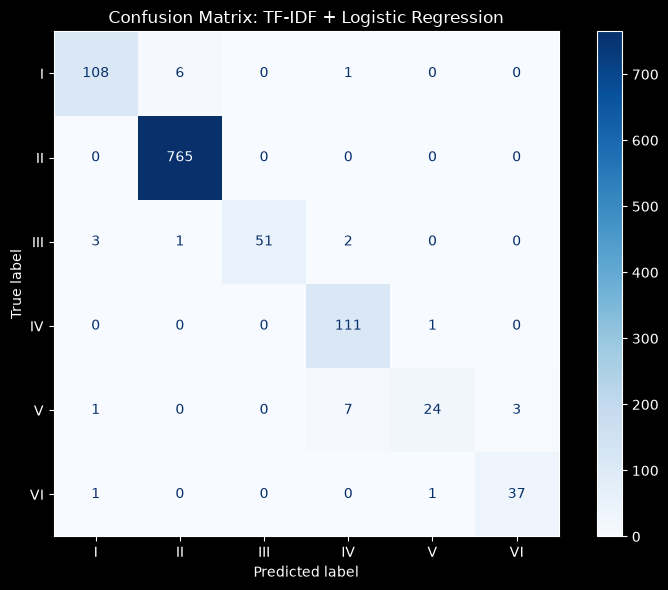

MLflow run ID: 2d73a8e5e78c41258fed4c85ea27d870

Macro-F1: 0.9273
Balanced accuracy: 0.9099

Recall каждого класса:
Bethesda I: 0.9391
Bethesda II: 1.0000
Bethesda III: 0.8947
Bethesda IV: 0.9911
Bethesda V: 0.6857
Bethesda VI: 0.9487
🏃 View run prepared_tfidf_logreg_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/2d73a8e5e78c41258fed4c85ea27d870
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [15]:
import matplotlib.pyplot as plt
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    recall_score,
    ConfusionMatrixDisplay,
)


# Фиксированный порядок классов для метрик и confusion matrix
classes = ["I", "II", "III", "IV", "V", "VI"]


# Создаём единый Pipeline:
# исходный текст -> TF-IDF -> Logistic Regression
model_run1 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_logreg_baseline"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params["min_df"],
        "tfidf_lowercase": tfidf_params["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params["max_iter"],
        "logreg_random_state": logreg_params["random_state"],
        "logreg_class_weight": str(
            logreg_params["class_weight"]
        ),
    })

    # Обучаем модель только на train
    model_run1.fit(X_train, y_train)

    # Получаем предсказания для test
    y_pred_run1 = model_run1.predict(X_test)

    # Основные метрики
    macro_f1_run1 = f1_score(
        y_test,
        y_pred_run1,
        average="macro",
    )

    balanced_acc_run1 = balanced_accuracy_score(
        y_test,
        y_pred_run1,
    )

    # Recall отдельно для каждого класса Bethesda
    recall_per_class_run1 = recall_score(
        y_test,
        y_pred_run1,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Сохраняем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run1,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run1,
    )

    # Сохраняем recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run1,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Строим confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run1,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: TF-IDF + Logistic Regression"
    )

    plt.tight_layout()

    # Сохраняем confusion matrix в MLflow
    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь обученный Pipeline
    mlflow.sklearn.log_model(
        sk_model=model_run1,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)
    print()
    print(f"Macro-F1: {macro_f1_run1:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run1:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run1,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Результаты baseline

Первый воспроизводимый baseline `TF-IDF + Logistic Regression` на
`prepared_dataset.csv` показал следующие результаты:

- `macro-F1 = 0.9273`;
- `balanced accuracy = 0.9099`.

Модель хорошо распознаёт большинство классов Bethesda. Наиболее высокий recall
получен для Bethesda II и IV.

Наиболее слабым классом является Bethesda V:

- recall Bethesda V = `0.6857`;
- из 35 объектов класса V правильно классифицированы 24;
- 7 объектов были отнесены к Bethesda IV;
- 3 объекта - к Bethesda VI;
- 1 объект - к Bethesda I.

Одной из возможных причин является выраженный дисбаланс классов: Bethesda II
составляет большую часть обучающей выборки, тогда как Bethesda V представлен
значительно меньшим количеством объектов.

Следующий эксперимент проверяет, улучшит ли автоматическая балансировка весов
классов распознавание редких категорий.

## Эксперимент 2: Logistic Regression с балансировкой классов

Во втором эксперименте изменяется только параметр `class_weight` модели
Logistic Regression:

`None` → `"balanced"`.

Параметры TF-IDF, train/test split и `random_state` остаются неизменными.

При `class_weight="balanced"` веса классов рассчитываются обратно
пропорционально количеству объектов каждого класса в обучающей выборке.
Ошибки на редких классах получают больший вес при оптимизации модели.

Цель эксперимента - проверить, повысится ли качество распознавания редких
категорий Bethesda, прежде всего Bethesda V, без существенного ухудшения
общего качества классификации.

In [16]:
# TF-IDF оставляем без изменений
tfidf_params_run2 = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "lowercase": True,
}

# Единственное изменение - балансировка классов
logreg_params_run2 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("TF-IDF parameters:")
print(tfidf_params_run2)

print("\nLogistic Regression parameters:")
print(logreg_params_run2)

TF-IDF parameters:
{'ngram_range': (1, 1), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


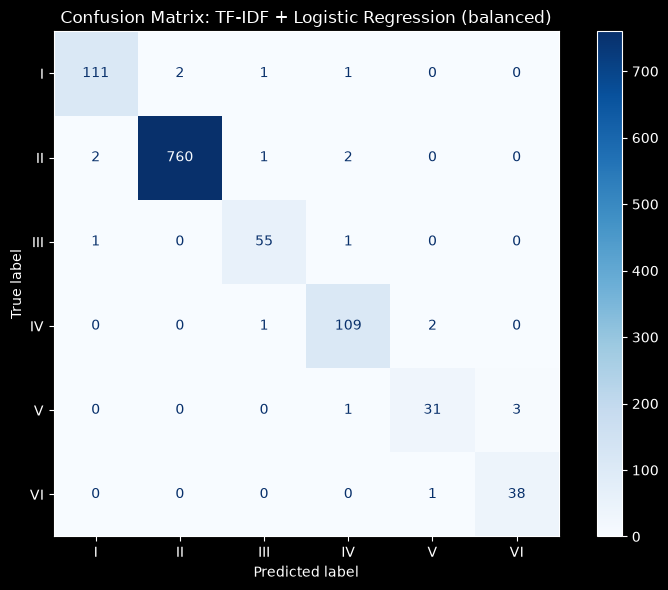

MLflow run ID: ece9684356524facb8a7f2a5d3b9f1d4

Macro-F1: 0.9558
Balanced accuracy: 0.9595

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9935
Bethesda III: 0.9649
Bethesda IV: 0.9732
Bethesda V: 0.8857
Bethesda VI: 0.9744
🏃 View run prepared_tfidf_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/ece9684356524facb8a7f2a5d3b9f1d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [19]:
# Создаём Pipeline для второго эксперимента
model_run2 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params_run2),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run2),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params_run2["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params_run2["min_df"],
        "tfidf_lowercase": tfidf_params_run2["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run2["max_iter"],
        "logreg_random_state": logreg_params_run2["random_state"],
        "logreg_class_weight": logreg_params_run2["class_weight"],
    })

    # Обучение
    model_run2.fit(X_train, y_train)

    # Предсказания
    y_pred_run2 = model_run2.predict(X_test)

    # Метрики
    macro_f1_run2 = f1_score(
        y_test,
        y_pred_run2,
        average="macro",
    )

    balanced_acc_run2 = balanced_accuracy_score(
        y_test,
        y_pred_run2,
    )

    recall_per_class_run2 = recall_score(
        y_test,
        y_pred_run2,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run2,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run2,
    )

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run2,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run2,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: TF-IDF + Logistic Regression (balanced)"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем Pipeline целиком
    mlflow.sklearn.log_model(
        sk_model=model_run2,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)
    print()
    print(f"Macro-F1: {macro_f1_run2:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run2:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run2,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Сравнение экспериментов 1 и 2

Во втором эксперименте было изменено только значение `class_weight`
в Logistic Regression:

`None` → `"balanced"`.

Параметры TF-IDF, train/test split и `random_state` оставались неизменными,
поэтому различия результатов можно связать с применением балансировки классов.

| Метрика | Baseline | Balanced |
|---|---:|---:|
| Macro-F1 | 0.9273 | 0.9558 |
| Balanced accuracy | 0.9099 | 0.9595 |

Балансировка улучшила качество распознавания большинства редких классов:

- Bethesda I: recall `0.9391 → 0.9652`;
- Bethesda III: `0.8947 → 0.9649`;
- Bethesda V: `0.6857 → 0.8857`;
- Bethesda VI: `0.9487 → 0.9744`.

Наиболее значительное улучшение наблюдается для Bethesda V:
recall увеличился на `0.2000`. В baseline из 35 тестовых объектов класса V
правильно определялись 24, после балансировки - 31.

При этом recall Bethesda II немного снизился с `1.0000` до `0.9935`,
а Bethesda IV - с `0.9911` до `0.9732`.

Такое изменение соответствует ожидаемому действию `class_weight="balanced"`:
ошибки на менее представленных классах получают больший вес при обучении,
за счёт чего модель меньше ориентируется на преобладающие классы.

По совокупности `macro-F1`, `balanced accuracy` и recall редких категорий
вариант с `class_weight="balanced"` является лучшим из двух текущих экспериментов.

## Эксперимент 3: добавление биграмм в TF-IDF

В третьем эксперименте сохраняется лучшая конфигурация Logistic Regression
из предыдущего запуска с `class_weight="balanced"`.

Изменяется только параметр TF-IDF:

`ngram_range=(1, 1)` → `ngram_range=(1, 2)`.

Теперь в качестве признаков используются не только отдельные слова,
но и пары соседних слов - биграммы.

Это позволяет модели учитывать устойчивые словосочетания, которые могут быть
информативнее отдельных терминов.

Цель эксперимента - проверить, улучшит ли использование биграмм качество
классификации по `macro-F1`, `balanced accuracy` и recall отдельных классов Bethesda.

In [22]:
# В третьем эксперименте добавляем биграммы
tfidf_params_run3 = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "lowercase": True,
}

# Logistic Regression оставляем без изменений
logreg_params_run3 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("TF-IDF parameters:")
print(tfidf_params_run3)

print("\nLogistic Regression parameters:")
print(logreg_params_run3)

TF-IDF parameters:
{'ngram_range': (1, 2), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


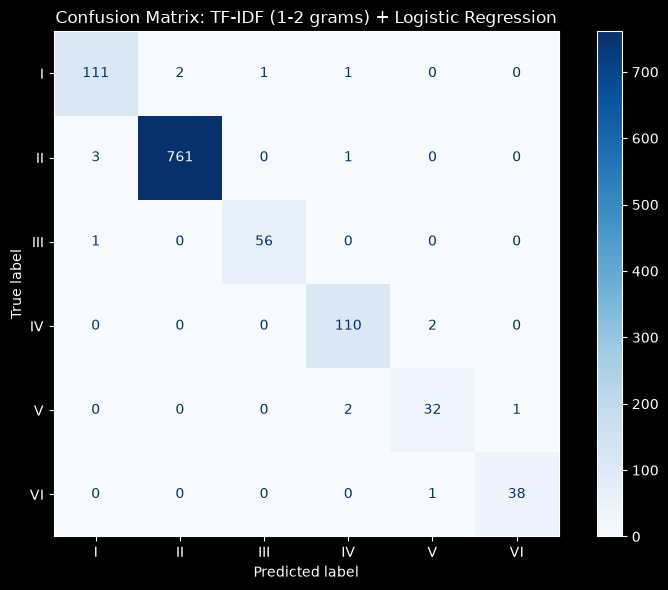

MLflow run ID: c91f4e5e53284339bad7ba49230072a5

Macro-F1: 0.9676
Balanced accuracy: 0.9689

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9948
Bethesda III: 0.9825
Bethesda IV: 0.9821
Bethesda V: 0.9143
Bethesda VI: 0.9744
🏃 View run prepared_tfidf_bigram_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/c91f4e5e53284339bad7ba49230072a5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [23]:
# Создаём Pipeline с униграммами и биграммами
model_run3 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params_run3),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run3),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_bigram_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params_run3["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params_run3["min_df"],
        "tfidf_lowercase": tfidf_params_run3["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run3["max_iter"],
        "logreg_random_state": logreg_params_run3["random_state"],
        "logreg_class_weight": logreg_params_run3["class_weight"],
    })

    # Обучение модели
    model_run3.fit(X_train, y_train)

    # Предсказания на тестовой выборке
    y_pred_run3 = model_run3.predict(X_test)

    # Основные метрики
    macro_f1_run3 = f1_score(
        y_test,
        y_pred_run3,
        average="macro",
    )

    balanced_acc_run3 = balanced_accuracy_score(
        y_test,
        y_pred_run3,
    )

    # Recall по каждому классу Bethesda
    recall_per_class_run3 = recall_score(
        y_test,
        y_pred_run3,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run3,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run3,
    )

    # Логируем recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run3,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run3,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: TF-IDF (1-2 grams) + Logistic Regression"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем обученный Pipeline
    mlflow.sklearn.log_model(
        sk_model=model_run3,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)
    print()
    print(f"Macro-F1: {macro_f1_run3:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run3:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run3,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Сравнение экспериментов 2 и 3

В третьем эксперименте к униграммам TF-IDF были добавлены биграммы:

`ngram_range=(1, 1)` → `ngram_range=(1, 2)`.

Остальные параметры модели, включая `class_weight="balanced"`,
train/test split и `random_state`, оставались неизменными.

| Метрика | Balanced | Balanced + bigrams |
|---|---:|---:|
| Macro-F1 | 0.9558 | 0.9676 |
| Balanced accuracy | 0.9595 | 0.9689 |

Использование биграмм улучшило обе основные метрики.

Изменение recall по классам:

- Bethesda I: `0.9652 → 0.9652`;
- Bethesda II: `0.9935 → 0.9948`;
- Bethesda III: `0.9649 → 0.9825`;
- Bethesda IV: `0.9732 → 0.9821`;
- Bethesda V: `0.8857 → 0.9143`;
- Bethesda VI: `0.9744 → 0.9744`.

Наиболее заметное дополнительное улучшение получено для Bethesda V.
Из 35 тестовых объектов этого класса модель правильно классифицировала 32.

Полученный результат показывает, что пары соседних слов содержат полезную
для классификации информацию, которую модель не полностью получает при
использовании только отдельных слов.

На текущем этапе конфигурация

`TF-IDF ngram_range=(1, 2) + Logistic Regression class_weight="balanced"`

является лучшей среди проведённых экспериментов.

## Эксперимент 4: лемматизация текста

В четвёртом эксперименте проверяется влияние лемматизации русскоязычных
медицинских текстов.

В качестве основы используется лучшая конфигурация предыдущего эксперимента:

- TF-IDF с `ngram_range=(1, 2)`;
- `min_df=2`;
- Logistic Regression с `class_weight="balanced"`;
- тот же train/test split;
- `random_state=42`.

Единственным концептуальным изменением является добавление лемматизации
с помощью `pymorphy3`.

Перед построением TF-IDF русские слова приводятся к нормальной форме.
Латинские обозначения и числовые токены сохраняются без морфологического
преобразования.

Цель эксперимента - проверить, уменьшает ли нормализация словоформ
разреженность признакового пространства и улучшает ли качество
классификации Bethesda.

In [24]:
import re
from functools import lru_cache
from importlib.metadata import version

import pymorphy3


# Морфологический анализатор русского языка
morph = pymorphy3.MorphAnalyzer()

# Используем токены длиной от двух символов.
# Это близко к стандартному поведению TfidfVectorizer.
token_pattern = re.compile(r"(?u)\b\w\w+\b")

# Отдельно определяем русские слова.
russian_word_pattern = re.compile(r"^[а-яё]+$")


@lru_cache(maxsize=100_000)
def lemmatize_token(token):
    """
    Приводит русский токен к нормальной форме.
    Остальные токены оставляет без изменений.
    """
    if russian_word_pattern.fullmatch(token):
        return morph.parse(token)[0].normal_form

    return token


def lemmatize_text(text):
    """
    Токенизирует текст и выполняет лемматизацию русских слов.
    """
    tokens = token_pattern.findall(str(text).lower())

    lemmas = [
        lemmatize_token(token)
        for token in tokens
    ]

    return " ".join(lemmas)


pymorphy3_version = version("pymorphy3")

print("pymorphy3 version:", pymorphy3_version)

pymorphy3 version: 2.0.6


In [25]:
# TF-IDF остаётся с униграммами и биграммами.
# lowercase=False, потому что приведение к нижнему регистру
# уже выполняется внутри lemmatize_text().
tfidf_params_run4 = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "lowercase": False,
}

# Параметры Logistic Regression не меняем
logreg_params_run4 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("TF-IDF parameters:")
print(tfidf_params_run4)

print("\nLogistic Regression parameters:")
print(logreg_params_run4)

TF-IDF parameters:
{'ngram_range': (1, 2), 'min_df': 2, 'lowercase': False}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


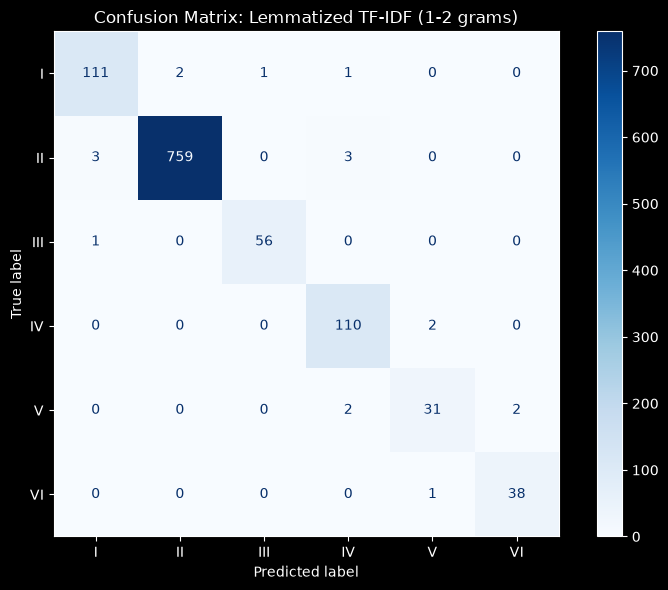

2026/10/11 01:31:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/11 01:31:48 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/md/w76kjnk11_1gxm2_wn38wd5c0000gn/T/tmpk6yhjwmc/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.9.1', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


MLflow run ID: fe7ae8055d3b444fa20cb5bf0deed9e1

Macro-F1: 0.9613
Balanced accuracy: 0.9637

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9922
Bethesda III: 0.9825
Bethesda IV: 0.9821
Bethesda V: 0.8857
Bethesda VI: 0.9744
🏃 View run prepared_tfidf_bigram_lemmatized_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/fe7ae8055d3b444fa20cb5bf0deed9e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [32]:
# Создаём Pipeline с лемматизацией текста
model_run4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            **tfidf_params_run4,
            preprocessor=lemmatize_text,
        ),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run4),
    ),
])


with mlflow.start_run(
    run_name="prepared_tfidf_bigram_lemmatized_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Информация о предобработке
    mlflow.log_params({
        "lemmatization": True,
        "lemmatizer": "pymorphy3",
        "pymorphy3_version": pymorphy3_version,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(
            tfidf_params_run4["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params_run4["min_df"],
        "tfidf_lowercase": tfidf_params_run4["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run4["max_iter"],
        "logreg_random_state": logreg_params_run4["random_state"],
        "logreg_class_weight": logreg_params_run4["class_weight"],
    })

    # Обучение модели
    model_run4.fit(X_train, y_train)

    # Предсказания на тестовой выборке
    y_pred_run4 = model_run4.predict(X_test)

    # Основные метрики
    macro_f1_run4 = f1_score(
        y_test,
        y_pred_run4,
        average="macro",
    )

    balanced_acc_run4 = balanced_accuracy_score(
        y_test,
        y_pred_run4,
    )

    # Recall отдельно для каждого класса Bethesda
    recall_per_class_run4 = recall_score(
        y_test,
        y_pred_run4,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run4,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run4,
    )

    # Логируем recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run4,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Строим confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run4,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: Lemmatized TF-IDF (1-2 grams)"
    )

    plt.tight_layout()

    # Сохраняем confusion matrix в MLflow
    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь Pipeline.
    # Используем cloudpickle, так как Pipeline содержит
    # пользовательскую функцию lemmatize_text().
    mlflow.sklearn.log_model(
        sk_model=model_run4,
        name="model",
        serialization_format="cloudpickle",
        extra_pip_requirements=[
            f"pymorphy3=={pymorphy3_version}",
        ],
    )

    # Выводим результаты эксперимента
    print("MLflow run ID:", run.info.run_id)
    print()

    print(f"Macro-F1: {macro_f1_run4:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run4:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run4,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Результаты эксперимента с лемматизацией

В четвёртом эксперименте к лучшей конфигурации предыдущего запуска была
добавлена лемматизация русскоязычного текста с помощью `pymorphy3`.

Остальные основные параметры модели сохранялись:

- `ngram_range=(1, 2)`;
- `min_df=2`;
- `class_weight="balanced"`;
- тот же train/test split;
- `random_state=42`.

### Сравнение с лучшей моделью без лемматизации

| Метрика | Без лемматизации | С лемматизацией |
|---|---:|---:|
| Macro-F1 | 0.9676 | 0.9613 |
| Balanced accuracy | 0.9689 | 0.9637 |

Recall по классам:

- Bethesda I: `0.9652 → 0.9652`;
- Bethesda II: `0.9948 → 0.9922`;
- Bethesda III: `0.9825 → 0.9825`;
- Bethesda IV: `0.9821 → 0.9821`;
- Bethesda V: `0.9143 → 0.8857`;
- Bethesda VI: `0.9744 → 0.9744`.

Лемматизация не улучшила качество классификации.
Macro-F1 снизился на `0.0063`, а balanced accuracy - на `0.0052`.

Наиболее заметное ухудшение наблюдается для Bethesda V:
recall снизился с `0.9143` до `0.8857`.

Таким образом, дополнительная морфологическая нормализация не является
полезной для текущей конфигурации TF-IDF. В дальнейших экспериментах в
качестве основной конфигурации сохраняется вариант без лемматизации:

`TF-IDF ngram_range=(1, 2) + Logistic Regression class_weight="balanced"`.

## Эксперимент 5: символьный TF-IDF

В пятом эксперименте проверяется альтернативное представление текста с помощью
символьных n-грамм.

Вместо отдельных слов и пар слов TF-IDF строится по последовательностям
из 3-5 символов внутри границ слов:

`analyzer="char_wb", ngram_range=(3, 5)`.

Такой подход позволяет учитывать общие части различных словоформ без явной
лемматизации. Это может быть особенно полезно для русскоязычных медицинских
текстов, содержащих морфологически связанные формы одних и тех же терминов.

Лемматизация в этом эксперименте не используется.

Параметры Logistic Regression сохраняются от лучшей конфигурации:

- `class_weight="balanced"`;
- `max_iter=1000`;
- `random_state=42`.

Train/test split также остаётся неизменным.

Цель эксперимента - проверить, будет ли символьное представление текста
эффективнее лучшего word-level TF-IDF с униграммами и биграммами.

In [33]:
# В Run 5 используем символьный TF-IDF
tfidf_params_run5 = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "min_df": 2,
    "lowercase": True,
}

# Logistic Regression оставляем без изменений
logreg_params_run5 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("TF-IDF parameters:")
print(tfidf_params_run5)

print("\nLogistic Regression parameters:")
print(logreg_params_run5)

TF-IDF parameters:
{'analyzer': 'char_wb', 'ngram_range': (3, 5), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


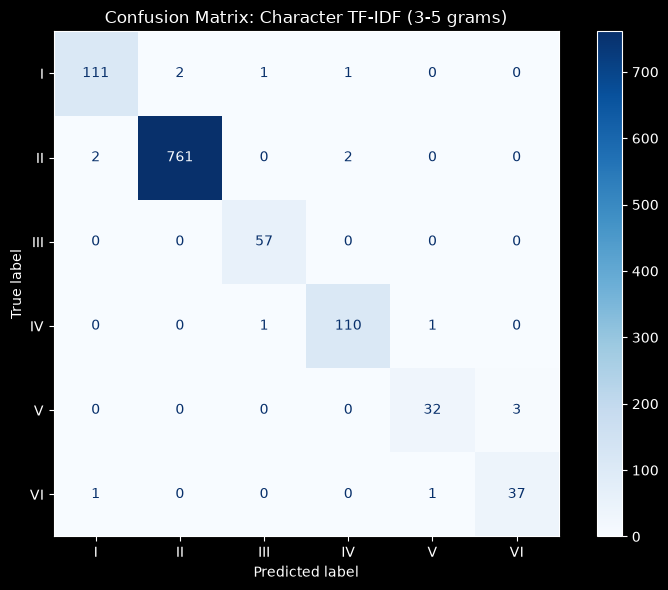

MLflow run ID: b2587c88dbcc47bf90799124e6f8e30a

Macro-F1: 0.9650
Balanced accuracy: 0.9675

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9948
Bethesda III: 1.0000
Bethesda IV: 0.9821
Bethesda V: 0.9143
Bethesda VI: 0.9487
🏃 View run prepared_char_tfidf_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/b2587c88dbcc47bf90799124e6f8e30a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [35]:
# Создаём Pipeline с символьным TF-IDF
model_run5 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params_run5),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run5),
    ),
])


with mlflow.start_run(
    run_name="prepared_char_tfidf_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "Character TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры TF-IDF
    mlflow.log_params({
        "tfidf_analyzer": tfidf_params_run5["analyzer"],
        "tfidf_ngram_range": str(
            tfidf_params_run5["ngram_range"]
        ),
        "tfidf_min_df": tfidf_params_run5["min_df"],
        "tfidf_lowercase": tfidf_params_run5["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run5["max_iter"],
        "logreg_random_state": logreg_params_run5["random_state"],
        "logreg_class_weight": logreg_params_run5["class_weight"],
    })

    # Обучение модели
    model_run5.fit(X_train, y_train)

    # Предсказания
    y_pred_run5 = model_run5.predict(X_test)

    # Основные метрики
    macro_f1_run5 = f1_score(
        y_test,
        y_pred_run5,
        average="macro",
    )

    balanced_acc_run5 = balanced_accuracy_score(
        y_test,
        y_pred_run5,
    )

    # Recall по каждому классу
    recall_per_class_run5 = recall_score(
        y_test,
        y_pred_run5,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run5,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run5,
    )

    # Логируем recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run5,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run5,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: Character TF-IDF (3-5 grams)"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь Pipeline
    mlflow.sklearn.log_model(
        sk_model=model_run5,
        name="model",
    )

    # Выводим результаты
    print("MLflow run ID:", run.info.run_id)
    print()

    print(f"Macro-F1: {macro_f1_run5:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run5:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run5,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

## Результаты эксперимента с символьным TF-IDF

В пятом эксперименте word-level TF-IDF был заменён на символьный TF-IDF:

`analyzer="char_wb", ngram_range=(3, 5)`.

Лемматизация не использовалась. Параметры Logistic Regression и train/test
split оставались неизменными.

### Сравнение с лучшей word-level моделью

| Метрика | Word TF-IDF | Character TF-IDF |
|---|---:|---:|
| Macro-F1 | 0.9676 | 0.9650 |
| Balanced accuracy | 0.9689 | 0.9675 |

Recall по классам:

- Bethesda I: `0.9652 → 0.9652`;
- Bethesda II: `0.9948 → 0.9948`;
- Bethesda III: `0.9825 → 1.0000`;
- Bethesda IV: `0.9821 → 0.9821`;
- Bethesda V: `0.9143 → 0.9143`;
- Bethesda VI: `0.9744 → 0.9487`.

Символьный TF-IDF показал качество, близкое к лучшей word-level модели,
и обеспечил идеальный recall для Bethesda III.

Однако основные метрики немного снизились из-за ухудшения распознавания
Bethesda VI.

Таким образом, символьные признаки содержат полезную информацию,
но отдельно не превосходят word-level TF-IDF.

Лучшей отдельной моделью остаётся конфигурация:

`Word TF-IDF ngram_range=(1, 2) + Logistic Regression class_weight="balanced"`.

## Эксперимент 6: объединение word и character TF-IDF

В шестом эксперименте объединяются два представления текста, исследованные
ранее по отдельности:

1. word-level TF-IDF с униграммами и биграммами:
   `ngram_range=(1, 2)`;

2. character-level TF-IDF:
   `analyzer="char_wb", ngram_range=(3, 5)`.

Для объединения пространств признаков используется `FeatureUnion`.

Таким образом, модель одновременно получает информацию:

- о конкретных словах;
- о сочетаниях соседних слов;
- о частях слов;
- о сходстве различных словоформ и вариантов написания терминов.

Лемматизация не используется.

Параметры Logistic Regression сохраняются:

- `class_weight="balanced"`;
- `max_iter=1000`;
- `random_state=42`.

Train/test split остаётся тем же.

Цель эксперимента - проверить, дополняют ли word-level и character-level
признаки друг друга и сможет ли их объединение превзойти лучшую отдельную
word-level модель.

In [36]:
from sklearn.pipeline import FeatureUnion


# Word-level TF-IDF из лучшего Run 3
word_tfidf_params_run6 = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "lowercase": True,
}

# Character-level TF-IDF из Run 5
char_tfidf_params_run6 = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "min_df": 2,
    "lowercase": True,
}

# Logistic Regression оставляем без изменений
logreg_params_run6 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

print("Word TF-IDF parameters:")
print(word_tfidf_params_run6)

print("\nCharacter TF-IDF parameters:")
print(char_tfidf_params_run6)

print("\nLogistic Regression parameters:")
print(logreg_params_run6)

Word TF-IDF parameters:
{'ngram_range': (1, 2), 'min_df': 2, 'lowercase': True}

Character TF-IDF parameters:
{'analyzer': 'char_wb', 'ngram_range': (3, 5), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced'}


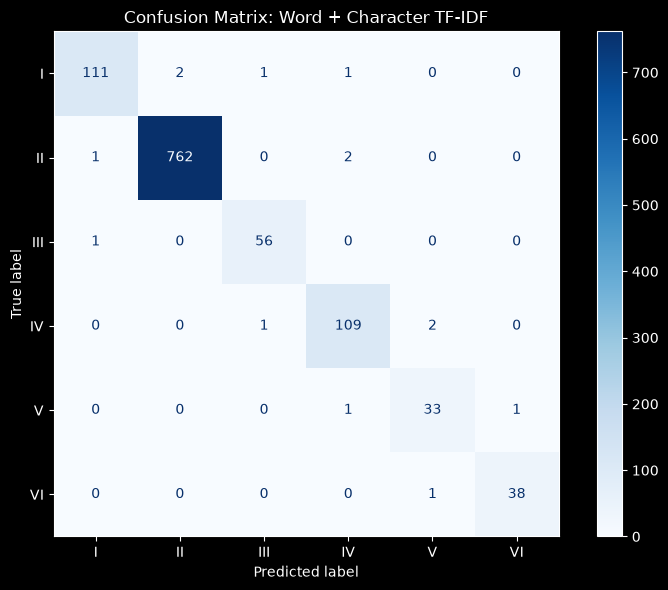

MLflow run ID: bc8a8eb12b6b497b8af8d951bc8c79aa

Macro-F1: 0.9695
Balanced accuracy: 0.9724

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9961
Bethesda III: 0.9825
Bethesda IV: 0.9732
Bethesda V: 0.9429
Bethesda VI: 0.9744

Количество признаков:
Word TF-IDF: 6511
Character TF-IDF: 18774
🏃 View run prepared_word_char_tfidf_logreg_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/bc8a8eb12b6b497b8af8d951bc8c79aa
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [38]:
# Объединяем word-level и character-level признаки
combined_features_run6 = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(**word_tfidf_params_run6),
    ),
    (
        "char_tfidf",
        TfidfVectorizer(**char_tfidf_params_run6),
    ),
])


# Создаём единый Pipeline
model_run6 = Pipeline([
    (
        "features",
        combined_features_run6,
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run6),
    ),
])


with mlflow.start_run(
    run_name="prepared_word_char_tfidf_logreg_balanced"
) as run:

    # Общая информация об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "Word + Character TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры word-level TF-IDF
    mlflow.log_params({
        "word_tfidf_ngram_range": str(
            word_tfidf_params_run6["ngram_range"]
        ),
        "word_tfidf_min_df": word_tfidf_params_run6["min_df"],
        "word_tfidf_lowercase": word_tfidf_params_run6["lowercase"],
    })

    # Параметры character-level TF-IDF
    mlflow.log_params({
        "char_tfidf_analyzer": char_tfidf_params_run6["analyzer"],
        "char_tfidf_ngram_range": str(
            char_tfidf_params_run6["ngram_range"]
        ),
        "char_tfidf_min_df": char_tfidf_params_run6["min_df"],
        "char_tfidf_lowercase": char_tfidf_params_run6["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run6["max_iter"],
        "logreg_random_state": logreg_params_run6["random_state"],
        "logreg_class_weight": logreg_params_run6["class_weight"],
    })

    # Обучение модели
    model_run6.fit(X_train, y_train)

    # Предсказания
    y_pred_run6 = model_run6.predict(X_test)

    # Основные метрики
    macro_f1_run6 = f1_score(
        y_test,
        y_pred_run6,
        average="macro",
    )

    balanced_acc_run6 = balanced_accuracy_score(
        y_test,
        y_pred_run6,
    )

    # Recall по каждому классу
    recall_per_class_run6 = recall_score(
        y_test,
        y_pred_run6,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Количество признаков каждого TF-IDF
    word_vectorizer_run6 = (
        model_run6
        .named_steps["features"]
        .transformer_list[0][1]
    )

    char_vectorizer_run6 = (
        model_run6
        .named_steps["features"]
        .transformer_list[1][1]
    )

    word_feature_count_run6 = len(
        word_vectorizer_run6.vocabulary_
    )

    char_feature_count_run6 = len(
        char_vectorizer_run6.vocabulary_
    )

    # Логируем основные метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run6,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run6,
    )

    # Логируем размеры пространств признаков
    mlflow.log_metric(
        "word_feature_count",
        word_feature_count_run6,
    )

    mlflow.log_metric(
        "char_feature_count",
        char_feature_count_run6,
    )

    # Recall каждого класса
    for class_name, recall_value in zip(
        classes,
        recall_per_class_run6,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run6,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        "Confusion Matrix: Word + Character TF-IDF"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь Pipeline
    mlflow.sklearn.log_model(
        sk_model=model_run6,
        name="model",
    )

    # Выводим результаты
    print("MLflow run ID:", run.info.run_id)
    print()

    print(f"Macro-F1: {macro_f1_run6:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run6:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run6,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )

    print("\nКоличество признаков:")
    print(
        "Word TF-IDF:",
        word_feature_count_run6,
    )
    print(
        "Character TF-IDF:",
        char_feature_count_run6,
    )

## Результаты объединения word и character TF-IDF

В шестом эксперименте были объединены два пространства признаков:

- word-level TF-IDF с `ngram_range=(1, 2)`;
- character-level TF-IDF с `analyzer="char_wb"` и `ngram_range=(3, 5)`.

Для объединения использовался `FeatureUnion`.

Количество сформированных признаков:

- word TF-IDF: `6511`;
- character TF-IDF: `18774`.

### Сравнение с лучшей отдельной word-level моделью

| Метрика | Word TF-IDF | Word + Character TF-IDF |
|---|---:|---:|
| Macro-F1 | 0.9676 | 0.9695 |
| Balanced accuracy | 0.9689 | 0.9724 |

Recall по классам:

- Bethesda I: `0.9652 → 0.9652`;
- Bethesda II: `0.9948 → 0.9961`;
- Bethesda III: `0.9825 → 0.9825`;
- Bethesda IV: `0.9821 → 0.9732`;
- Bethesda V: `0.9143 → 0.9429`;
- Bethesda VI: `0.9744 → 0.9744`.

Объединение двух типов признаков улучшило обе основные метрики.

Наиболее заметное улучшение получено для Bethesda V:
из 35 тестовых объектов правильно классифицированы 33.

При этом recall Bethesda IV немного снизился.

Результат показывает, что word-level и character-level признаки
частично дополняют друг друга. Word-признаки позволяют учитывать целые
термины и словосочетания, а символьные признаки дают дополнительную
информацию о морфологически связанных формах и частях медицинских терминов.

На текущем этапе лучшей конфигурацией является:

`Word TF-IDF (1, 2) + Character TF-IDF (3, 5) + Logistic Regression
class_weight="balanced"`.

Полученные результаты:

- `macro-F1 = 0.9695`;
- `balanced accuracy = 0.9724`.

## Эксперимент 7: настройка регуляризации Logistic Regression

В эксперименте сохраняется лучшая архитектура предыдущего
запуска:

- word-level TF-IDF с `ngram_range=(1, 2)`;
- character-level TF-IDF с `analyzer="char_wb"` и `ngram_range=(3, 5)`;
- объединение признаков через `FeatureUnion`;
- `class_weight="balanced"`.

Изменяется только параметр `C` модели Logistic Regression.

Параметр `C` определяет силу регуляризации:

- меньшее `C` означает более сильную регуляризацию;
- большее `C` означает более слабую регуляризацию.

Для выбора значения используются только объекты обучающей выборки.
На `X_train` выполняется стратифицированная 5-fold cross-validation
по значениям:

`C = [0.25, 0.5, 1.0, 2.0, 4.0]`.

Критерием выбора является `macro-F1`.

После выбора лучшего значения модель повторно обучается на всей
обучающей выборке и один раз оценивается на неизменной тестовой выборке.

Цель эксперимента - проверить, можно ли дополнительно улучшить лучшую
архитектуру за счёт настройки силы регуляризации.

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Word-level TF-IDF оставляем как в Run 6
word_tfidf_params_run7 = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "lowercase": True,
}

# Character-level TF-IDF оставляем как в Run 6
char_tfidf_params_run7 = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "min_df": 2,
    "lowercase": True,
}

# Базовые параметры Logistic Regression
logreg_params_run7 = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": "balanced",
}

# Проверяем несколько значений силы регуляризации
c_values_run7 = [0.25, 0.5, 1.0, 2.0, 4.0]

print("C values:")
print(c_values_run7)

C values:
[0.25, 0.5, 1.0, 2.0, 4.0]


In [ ]:
# Объединяем word-level и character-level признаки
combined_features_run7 = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(**word_tfidf_params_run7),
    ),
    (
        "char_tfidf",
        TfidfVectorizer(**char_tfidf_params_run7),
    ),
])


# Базовый Pipeline
pipeline_run7 = Pipeline([
    (
        "features",
        combined_features_run7,
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params_run7),
    ),
])


# Стратифицированная кросс-валидация
cv_run7 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


# Подбираем только параметр C
grid_search_run7 = GridSearchCV(
    estimator=pipeline_run7,
    param_grid={
        "logreg__C": c_values_run7,
    },
    scoring="f1_macro",
    cv=cv_run7,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)


with mlflow.start_run(
    run_name="prepared_word_char_tfidf_logreg_tuned_C"
) as run:

    # Общая информация
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": run_date,
        "git_commit": git_commit,
        "dataset_name": dataset_path.name,
        "dataset_version": dataset_hash,
        "model_name": "Word + Character TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Параметры word TF-IDF
    mlflow.log_params({
        "word_tfidf_ngram_range": str(
            word_tfidf_params_run7["ngram_range"]
        ),
        "word_tfidf_min_df": word_tfidf_params_run7["min_df"],
        "word_tfidf_lowercase": word_tfidf_params_run7["lowercase"],
    })

    # Параметры character TF-IDF
    mlflow.log_params({
        "char_tfidf_analyzer": char_tfidf_params_run7["analyzer"],
        "char_tfidf_ngram_range": str(
            char_tfidf_params_run7["ngram_range"]
        ),
        "char_tfidf_min_df": char_tfidf_params_run7["min_df"],
        "char_tfidf_lowercase": char_tfidf_params_run7["lowercase"],
    })

    # Параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params_run7["max_iter"],
        "logreg_random_state": logreg_params_run7["random_state"],
        "logreg_class_weight": logreg_params_run7["class_weight"],
    })

    # Параметры подбора
    mlflow.log_params({
        "cv_folds": 5,
        "cv_scoring": "f1_macro",
        "tested_C_values": str(c_values_run7),
    })

    # Подбор C выполняется только на train
    grid_search_run7.fit(
        X_train,
        y_train,
    )

    # Лучшее значение C
    best_c_run7 = grid_search_run7.best_params_[
        "logreg__C"
    ]

    best_cv_macro_f1_run7 = (
        grid_search_run7.best_score_
    )

    # GridSearchCV с refit=True уже переобучил
    # лучший вариант на всей train-выборке
    model_run7 = grid_search_run7.best_estimator_

    # Только теперь оцениваем модель на test
    y_pred_run7 = model_run7.predict(X_test)

    macro_f1_run7 = f1_score(
        y_test,
        y_pred_run7,
        average="macro",
    )

    balanced_acc_run7 = balanced_accuracy_score(
        y_test,
        y_pred_run7,
    )

    recall_per_class_run7 = recall_score(
        y_test,
        y_pred_run7,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Логируем выбранное C и CV-результат
    mlflow.log_param(
        "best_C",
        best_c_run7,
    )

    mlflow.log_metric(
        "best_cv_macro_f1",
        best_cv_macro_f1_run7,
    )

    # Финальные test-метрики
    mlflow.log_metric(
        "macro_f1",
        macro_f1_run7,
    )

    mlflow.log_metric(
        "balanced_accuracy",
        balanced_acc_run7,
    )

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run7,
    ):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_run7,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title(
        f"Confusion Matrix: Word + Character TF-IDF, C={best_c_run7}"
    )

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем лучшую модель
    mlflow.sklearn.log_model(
        sk_model=model_run7,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)

    print("\nЛучшее значение C:")
    print(best_c_run7)

    print("\nЛучший CV Macro-F1:")
    print(f"{best_cv_macro_f1_run7:.4f}")

    print("\nРезультат на test:")
    print(f"Macro-F1: {macro_f1_run7:.4f}")
    print(
        f"Balanced accuracy: "
        f"{balanced_acc_run7:.4f}"
    )

    print("\nRecall каждого класса:")

    for class_name, recall_value in zip(
        classes,
        recall_per_class_run7,
    ):
        print(
            f"Bethesda {class_name}: "
            f"{recall_value:.4f}"
        )